In [ ]:
                              # Part 2 – Unsupervised Learning (Dataset: Zomato User Behavior Data)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("D:\ML EXAM\zomato_user_data - LMS.csv")

df.head()

,user_id,city,device_type,subscription_status,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
0,ZOM200000,Hyderabad,iOS,NaN,Returning,North Indian,26.740168,8.965961,8.465340,4.815482,...,0.355390,0.629073,0.326298,0.451233,0.525325,8.390026,32.193597,0.019575,4.362833,0
1,ZOM200001,Kolkata,iOS,NaN,Returning,Chinese,10.145544,6.343538,10.526948,0.276121,...,0.227851,0.005544,0.643287,0.000000,0.434892,26.205100,26.341917,0.068982,4.295368,2
2,ZOM200002,Kolkata,Android,Zomato Gold,Returning,Italian,23.190429,7.971666,12.844486,3.517156,...,0.523863,0.338718,0.446290,0.250970,0.606698,13.669060,28.575752,0.049404,4.543003,0
3,ZOM200003,Hyderabad,Android,Zomato Gold,Returning,South Indian,13.083080,6.911308,9.543095,2.315705,...,0.342982,0.717055,0.215513,0.401037,0.628076,20.310362,21.667125,0.040058,4.286456,0
4,ZOM200004,Bangalore,Android,NaN,Long-Term,Desserts,61.488038,16.936118,5.490302,19.726369,...,0.279026,0.199145,0.292876,0.374529,0.398572,3.435409,40.145218,0.104421,3.827626,0


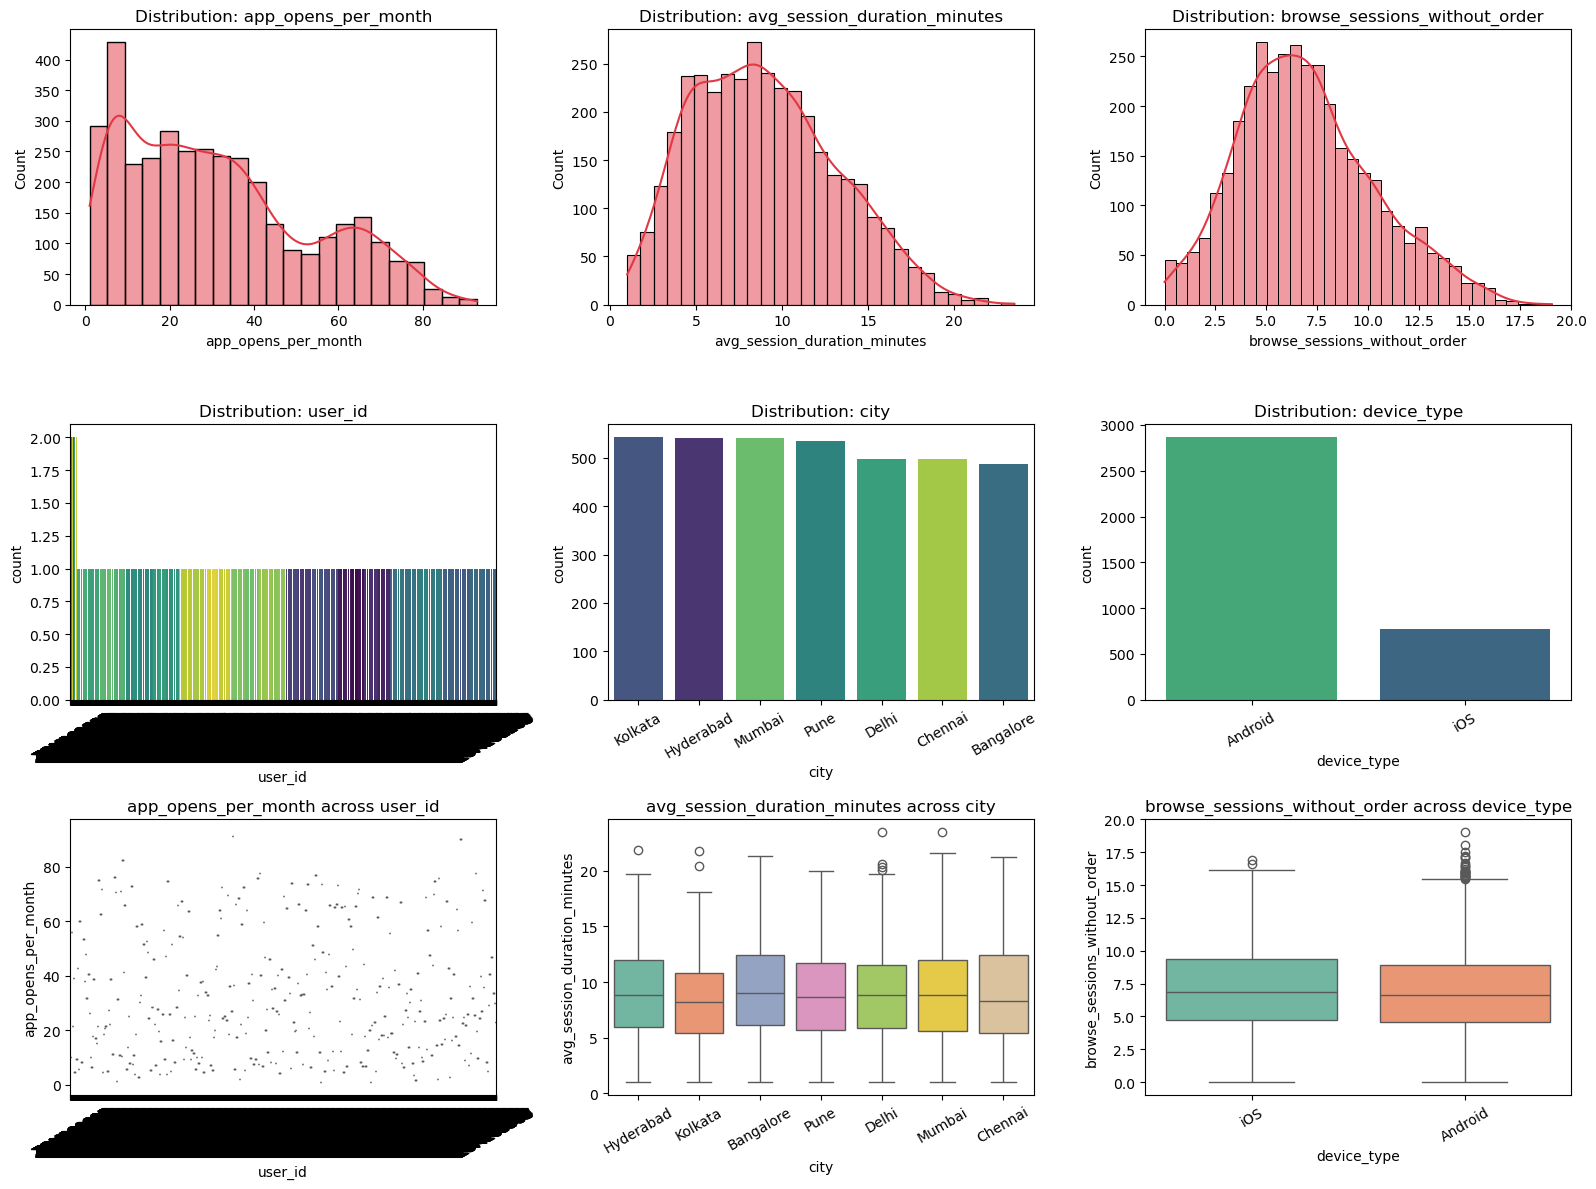

In [3]:
# Q1. Exploratory Data Analysis (EDA) (4 Marks)
# Perform exploratory data analysis on the given dataset and address the following points:
#●	Analyze the distribution of key numerical features related to user engagement and ordering behavior
# ●	Analyze at least three categorical variables such as city, device type, subscription status, or preferred cuisine
# ●	Summarize key observations that indicate differences in user usage patterns
# ●	Support your analysis with appropriate visualizations and explanations.

# ANS
# Target relevant features dynamically
num_cols = [c for c in df.select_dtypes('number') if 'id' not in c.lower()][:3]
cat_cols = df.select_dtypes(['object', 'category']).columns.tolist()[:3]

# Create a clean subplotted grid layout
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

# Row 1: Numerical Feature Distributions
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#E23744')
    axes[i].set_title(f'Distribution: {col}')

# Row 2: Categorical Feature Distributions
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[3+i], hue=col, palette='viridis', legend=False)
    axes[3+i].set_title(f'Distribution: {col}')
    axes[3+i].tick_params(axis='x', rotation=30)

# Row 3: Bivariate Usage Patterns (Behavioral differences)
for i, col in enumerate(cat_cols):
    if len(num_cols) > i:
        sns.boxplot(data=df, x=col, y=num_cols[i], ax=axes[6+i], hue=col, palette='Set2', legend=False)
        axes[6+i].set_title(f'{num_cols[i]} across {col}')
        axes[6+i].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


Duplicates found: 53
Missing values per column:
 subscription_status          2435
preferred_cuisine             128
avg_order_value               125
discount_usage_rate           117
avg_delivery_time_minutes     116
dtype: int64

Outlier Counts (IQR Method): {'app_opens_per_month': 0, 'avg_session_duration_minutes': 9, 'browse_sessions_without_order': 32}


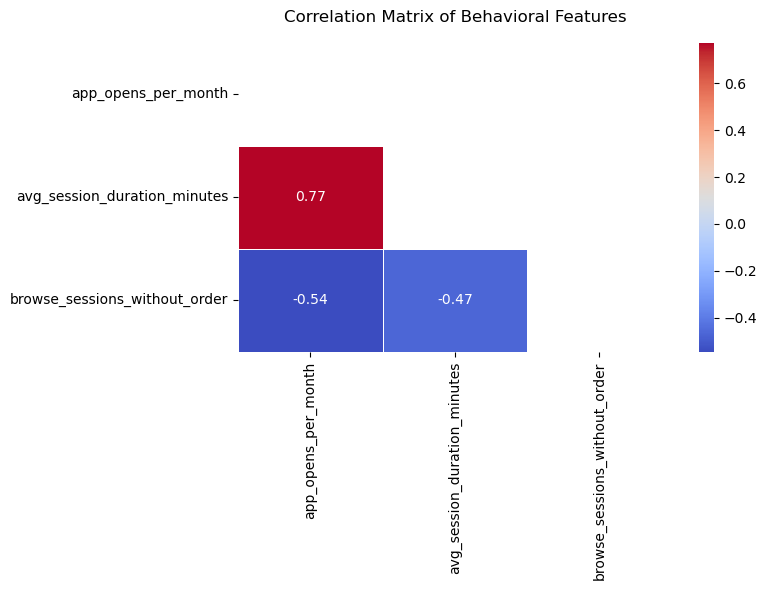

In [4]:
# Q2. Data Preparation and Exploration (6 Marks)
# Perform the following tasks:
# a)	Data Quality Analysis (2 Marks)
# ●	Identify missing values and duplicate records in the dataset
# ●	Apply suitable strategies to handle them

# b)	Outlier Detection (2 Marks)
# ●	Detect outliers in relevant numerical features using an appropriate statistical method
# ●	Comment on whether the detected outliers should be treated or retained

# c)	Correlation Analysis (2 Marks)
# ●	Identify correlated numerical features
# ●	Explain how correlation among features can affect clustering results

# ANS

# --- a) Data Quality Analysis ---
missing_counts = df.isnull().sum()
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
print("Missing values per column:\n", missing_counts[missing_counts > 0])

# Strategies: Drop exact duplicates, impute missing numbers with median
df = df.drop_duplicates()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# --- b) Outlier Detection (IQR Method) ---
outliers_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

print("\nOutlier Counts (IQR Method):", outliers_summary)

# --- c) Correlation Analysis ---
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols].corr()
# Mask upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, linewidths=0.5)
plt.title("Correlation Matrix of Behavioral Features", pad=15)
plt.tight_layout(); plt.show()



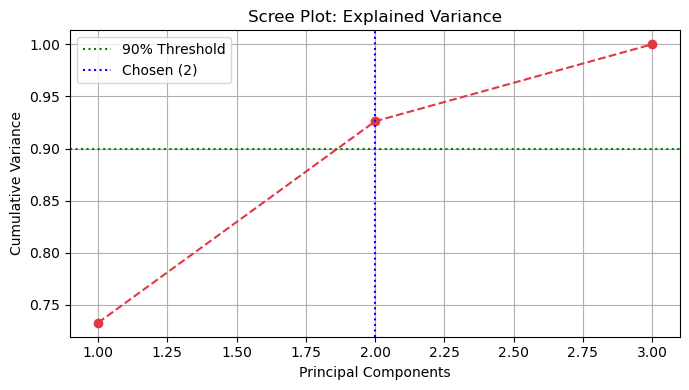

Components selected: 2
Total variance retained: 92.61%


In [7]:
# Q3. Dimensionality Reduction using PCA (4 Marks)
# ●	Standardize the numerical features used for clustering
# ●	Apply Principal Component Analysis (PCA) to reduce dimensionality
# ●	Select the number of principal components such that at least 90–95% of the variance is retained
# ●	Comment on the variance explained by the selected components

# ANS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # Fixes NameError

# 1. Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[num_cols])

# 2. Fit full PCA to find optimal variance
pca_full = PCA(random_state=42)
pca_full.fit(scaled_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Identify minimal components to cross 90% variance threshold
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

# 4. Fit final PCA on selected component depth
pca_optimal = PCA(n_components=n_components_90, random_state=42)
pca_transformed = pca_optimal.fit_transform(scaled_features)
df_pca = pd.DataFrame(pca_transformed, columns=[f'PC{i+1}' for i in range(n_components_90)])

# 5. Scree Plot Visualization
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', ls='--', color='#E23744')
plt.axhline(y=0.90, color='g', ls=':', label='90% Threshold')
plt.axvline(x=n_components_90, color='b', ls=':', label=f'Chosen ({n_components_90})')
plt.title('Scree Plot: Explained Variance')
plt.xlabel('Principal Components'); plt.ylabel('Cumulative Variance'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"Components selected: {n_components_90}")
print(f"Total variance retained: {cumulative_variance[n_components_90-1]*100:.2f}%")

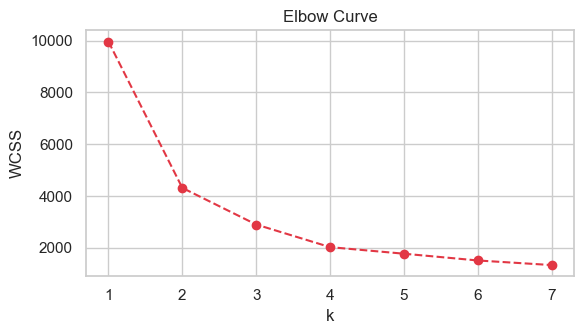

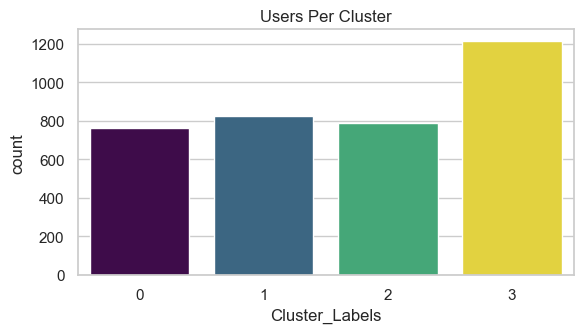


--- Profile Means ---
                app_opens_per_month  avg_session_duration_minutes  \
Cluster_Labels                                                      
0                             10.49                          4.69   
1                             14.91                          6.27   
2                             64.03                         14.44   
3                             34.46                          9.94   

                browse_sessions_without_order  
Cluster_Labels                                 
0                                        6.65  
1                                       11.66  
2                                        3.88  
3                                        6.02  


In [10]:
# Q4. Clustering and Interpretation (6 Marks)
# a)	Optimal Cluster Selection (3 Marks)
# ●	Determine the optimal number of clusters using the Elbow Method
# ●	Plot the elbow curve and justify the selected value of k

# b)	Model Building and Interpretation (3 Marks)
# ●	Build a K-Means clustering model using the chosen value of k
# ●	Visualize the distribution of users across clusters using an appropriate plot
# ●	Briefly describe the characteristics of each identified cluster based on feature patterns

# ANS
import os  # Fixes NameError: name 'os' is not defined
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Force Python to use a single isolated thread to bypass Windows hardware check
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
sns.set_theme(style="whitegrid")

# --- a) Optimal Cluster Selection ---
wcss = []
k_range = range(1, 8)

for k in k_range:
    # Setting n_init='auto' forces a cleaner, standard thread loop
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 3.5))
plt.plot(k_range, wcss, marker='o', ls='--', color='#E23744')
plt.title('Elbow Curve'); plt.xlabel('k'); plt.ylabel('WCSS'); plt.grid(True)
plt.tight_layout(); plt.show()

# --- b) Final Model Build ---
optimal_k = 4  
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto', random_state=42)
df['Cluster_Labels'] = kmeans_final.fit_predict(df_pca)

plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x='Cluster_Labels', hue='Cluster_Labels', palette='viridis', legend=False)
plt.title('Users Per Cluster'); plt.tight_layout(); plt.show()

# Print the resulting segmentation patterns
print("\n--- Profile Means ---")
print(df.groupby('Cluster_Labels')[num_cols].mean().round(2))
